## Housekeeping Settings

In [1]:
import numpy as np, pandas as pd, scanpy as sc, anndata as ad, matplotlib.pyplot as plt, os, logging, seaborn as sns, pickle
from scipy.stats import median_abs_deviation, hypergeom
import multiprocessing as mp, celloracle as co, glob, pickle
from functools import reduce
from collections import Counter
import itertools, math
import networkx as nx
import random

# visualization settings required to see plots in jupyter notebook
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

wd = '/ocean/projects/cis240075p/skeshari/igvf/bcell2/male_donor/'
out_path = os.path.join(wd, 'out_data', 'comb_ctrl')
os.makedirs(f"{out_path}/figures", exist_ok=True)
os.makedirs(f"{out_path}/out_files", exist_ok=True)
sc.settings.figdir = f"{out_path}/figures"

/ocean/projects/cis240075p/skeshari/.conda/envs/celloracle_env/lib/python3.8/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/ocean/projects/cis240075p/skeshari/.conda/envs/celloracle_env/lib/python3.8/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for detai

# SLIDE TF Enrichment

In [2]:
# Read oracle links after fitting
oracle = co.load_hdf5(f"{wd}/out_data/grn_inference/out_files/oracle_fitted.celloracle.oracle")
links_after_fit = {key: [] for key in oracle.coef_matrix_per_cluster.keys()}
CO_TFs = []
for cluster in oracle.coef_matrix_per_cluster.keys():
    cluster_specific_links = oracle.coef_matrix_per_cluster[cluster].stack().reset_index()
    cluster_specific_links.columns = ['source', 'target', 'coef_mean']
    cluster_specific_links = cluster_specific_links[cluster_specific_links ['coef_mean'] != 0].reset_index(drop=True)
    cluster_specific_links['coef_abs'] = np.abs(cluster_specific_links['coef_mean'])
    links_after_fit[cluster] = cluster_specific_links
    # links_after_fit[cluster]['weight'] = links_after_fit[cluster]['coef_abs'] * links_after_fit[cluster]['-logp']
    CO_TFs = CO_TFs + list(links_after_fit[cluster].source.unique())

In [9]:
def read_data(experiment):
    # read SLIDE data
    feature_files = glob.glob(f"{wd}/out_data/out_other_methods/SLIDE_Runs/{experiment}/*/*feature_list*")
    feature_data = [pd.read_csv(file, sep='\t', header = 0) for file in feature_files]
    feature_data = pd.concat(feature_data)
    slide_features = set(feature_data['names'])
    slide_TF = slide_features.intersection(CO_TFs)
    slide_genes = slide_features.difference(CO_TFs)
    return slide_TF, slide_genes

def classify_weights(weights, threshold):
    strong, weak = 0, np.inf
    for weight in weights:
        if abs(weight) > threshold and abs(weight) > abs(strong) :
            strong = weight
        elif abs(weight) < threshold and abs(weight) < abs(weak):
            weak = weight
    return [weak, strong]

def enrichment(M,n,N,X):
    # M is the total number of items in the population ===> Total starting genes in SLIDE
    # n is the number of successes in the population ===> Downstream genes
    # N is the sample size ===> Total SLIDE genes in LF
    # X is the number of successes in the sample.
    p_value = 1 - hypergeom.cdf(X-1, M, n, N)   # Compute the p-value for observing X or more successes
    score = math.log2((X/n)/(N/M))
    return (score, p_value)

def LF_enrichment(cc_dict, cluster_fusion, order_of_combination, suffix=None):
    enrichment_df = pd.DataFrame(cc_dict[cluster_fusion][order_of_combination], columns=['TF', 'Condition', 'ES', 'Genes'])
    enrichment_df[['Score', 'p_value']] = pd.DataFrame(enrichment_df['ES'].tolist(), index=enrichment_df.index)
    enrichment_df[['common', 'cmn_wt_list' , 'dwnstrm', 'dwn_wt_list']] = pd.DataFrame(enrichment_df['Genes'].tolist(), index=enrichment_df.index)
    enrichment_df = enrichment_df.drop(columns=['ES', 'Genes'])
    filter_enrichment_df = (enrichment_df['p_value']<1) \
                            & (enrichment_df['dwnstrm'].apply(len)>1) & (enrichment_df['common'].apply(len)>1) \
                            & (enrichment_df['Score']>0) & (enrichment_df['Condition']==(1,))
    enrichment_df = enrichment_df[filter_enrichment_df].sort_values(by='Score', ascending=False)
    enrichment_df.to_csv(f"{out_path}/out_files/SLIDE_LF_enriched_{order_of_combination}_TFs_{cluster_fusion}{suffix}.csv", index=False)
    return enrichment_df

def plot_graph(enrichment_df, suffix = None):
    G = nx.DiGraph()

    # Add edges with weights
    tfs = []
    for _, row in enrichment_df.iterrows():
        tf = row['TF'][0]
        tfs.append(tf)
        for gene, wt in zip(row['common'], row['cmn_wt_list']):
            G.add_edge(tf, gene, weight=wt[0])

    # Node colors
    node_colors = []
    for node in G.nodes():
        if node in tfs:
            node_colors.append("dodgerblue")  # TFs
        else:
            node_colors.append("lightskyblue")  # Genes

    # Get edge weights
    # weights = [G[u][v]['weight']*5 for u,v in G.edges()]  # scale up for visibility
    edges = G.edges()
    weights = []
    edge_colors = []
    for u, v in edges:
        w = G[u][v]['weight']
        weights.append(abs(w) * 5)  # Thickness scaled, abs to avoid negative widths
        if w >= 0:
            edge_colors.append('green')
        else:
            edge_colors.append('red')

    # Draw the graph
    plt.figure(figsize=(10, 7))
    pos = nx.kamada_kawai_layout(G)
    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors,
            width=weights, node_size=800, font_size=10, arrowsize=15)
    plt.title(f"{suffix} TF → Common Gene Network (Weighted Edges)")
    plt.tight_layout()
    plt.savefig(f"{out_path}/figures/SLIDE_LF_enrichment_network{suffix}.pdf")

def LF_enrichment1(slide_starting_genes, slide_genes, slide_TF, clusters_of_interest, order_fr_clust, order_fr_tfcomb, weight):
    cc_dict = {}
    for order_of_cluster in order_fr_clust:
        cluster_fusions = list(itertools.combinations(clusters_of_interest, order_of_cluster))
        for cluster_fusion in cluster_fusions:
            # Step1: Building fusion GRNs
            combined_links = (pd.concat([links_after_fit[cluster_id] for cluster_id in cluster_fusion]).sort_values(by=weight, ascending=False))
            # combined_links = pd.DataFrame()
            # for cluster_id in cluster_fusion:
            #     combined_links = pd.concat([combined_links, links_after_fit[cluster_id]]).sort_values(by=weight, ascending=False)
            combined_links['sorted_source'] = combined_links[['source', 'target']].min(axis=1)
            combined_links['sorted_target'] = combined_links[['source', 'target']].max(axis=1)
            # Step2: Classifying the weights of fusion GRNs and generating graph
            min_weight_threshold = abs(combined_links[weight]).quantile(0.90)
            print(f"Minimum weight threshold for {cluster_fusion}: {min_weight_threshold}")
            grouped_df = combined_links.groupby(['sorted_source', 'sorted_target'])[weight].apply(lambda x: classify_weights(x, min_weight_threshold)).reset_index()
            graph = nx.from_pandas_edgelist(grouped_df, source='sorted_source', target='sorted_target',edge_attr=weight).to_undirected()
            # Step3: Integrating SLIDE and GRN to get the total source and target
            slide_genes_TF = list(combined_links[combined_links['target'].isin(slide_genes)]['source'].unique())
            total_source = set(slide_TF).union(set(slide_genes_TF)).intersection(graph.nodes)
            total_target = set(slide_TF).union(set(slide_genes)).intersection(graph.nodes)
            # del combined_links
            # Step4: Finding TF combinations
            for order_of_combination in order_fr_tfcomb:
                possible_TF_combinations = list(itertools.combinations(total_source, order_of_combination))
                cnds_of_int_for_TF_comb = list(itertools.product([0, 1], repeat=order_of_combination))
                cc_dict.setdefault(cluster_fusion, {}).setdefault(order_of_combination, [])
                for TF_comb in possible_TF_combinations:
                    # Step4.1: Performing enrichment analysis
                    for condition in cnds_of_int_for_TF_comb:
                        common, dwngene = 0, 0
                        cmn_list, cmn_wt_list, dwn_list, dwn_wt_list = [], [], [], []
                        common_targets_from_grn = reduce(set.intersection, map(lambda TF: set(graph[TF].keys()), TF_comb))
                        for target in common_targets_from_grn:
                            # 0 is for weak, 1 is for strong since the weights are classified as [weak, strong]
                            # all(): Ensures that all the conditions hold true for every TF-cond pair.
                            if all(abs(graph[TF][target].get(weight, None)[cond]) > 0 for TF, cond in zip(TF_comb, condition)): # counts for classified weights should be greater than 0
                                dwngene+=1; dwn_list.append(target)
                                dwn_wt_list.append([graph[TF][target].get(weight, None)[cond] for TF, cond in zip(TF_comb, condition)])
                                if target in total_target: 
                                    common+=1; cmn_list.append(target) # enriched in SLIDE LF, increase common
                                    cmn_wt_list.append([graph[TF][target].get(weight, None)[cond] for TF, cond in zip(TF_comb, condition)]) # add the weights of the common targets
                        # If no common targets or no downstream genes, set enrichment to 0, pval to 1
                        if dwngene==0 or common==0:
                            cc_dict[cluster_fusion][order_of_combination].append([TF_comb, (condition), (0,1), (cmn_list, cmn_wt_list, dwn_list, dwn_wt_list)])
                        else:
                            cc_dict[cluster_fusion][order_of_combination].append([TF_comb, (condition), enrichment(slide_starting_genes,dwngene,len(total_target),common), (cmn_list, cmn_wt_list, dwn_list, dwn_wt_list)])
                # # Step5: Generating enrichment dataframe
                # enrichment_df = LF_enrichment(cc_dict, cluster_fusion, order_of_combination, f"_{M_cond}")
    return cc_dict

# Set inputs
# SLIDE based inputs
experiment = 'GC_ABC'
slide_starting_genes = 4603
slide_TF, slide_genes = read_data(experiment)
# Enrichment based inputs
clusters_of_interest = ['1','3']
order_fr_clust = [2] # clusters_of_interest_order = [1, 2, ...] # 1 for one cluster, 2 for two clusters
order_fr_tfcomb = [1] # tf_combination_order = [1, 2, ...] # 1 for one TF, 2 for two TFs
# CellOracle based inputs
weight = 'coef_mean'


master_dict = LF_enrichment1(slide_starting_genes, slide_genes, slide_TF, clusters_of_interest, order_fr_clust, order_fr_tfcomb, weight)

# # M_dict = {
# #     'PRDM1_KO': [['3','2','7','1'], [1], [1],4472],
# #     'IRF4_KO': [['3','2','7','1'], [1], [1],4500],
# #     'GC_PB': [['3','7'], ,4725],
# #     'PB_ABC': [['7','1'], ,3420],
# #     'GC_ABC': [['3','1'], ,4603]
# # }
# M_dict = {
#     # 'PRDM1_KO': 4472,
#     # 'IRF4_KO': 4500,
#     # 'GC_PB': 4725,
#     # 'PB_ABC': 3420,
#     'GC_ABC': 4603,
# }

# master_dict = {}
# for M_cond, M in M_dict.items():
#     slide_TF, slide_genes = read_data(M_cond)
#     cc_dict = {}
#     clusters_of_interest = ['1','3']
#     clusters_of_interest_order = [2] # clusters_of_interest_order = [1, 2, ...] # 1 for one cluster, 2 for two clusters
#     tf_combination_order = [1] # tf_combination_order = [1, 2, ...] # 1 for one TF, 2 for two TFs
#     # For each cluster, we will combine the links and classify the weights
#     for order_of_cluster in clusters_of_interest_order:
#         cluster_fusions = list(itertools.combinations(clusters_of_interest, order_of_cluster))
#         for cluster_fusion in cluster_fusions:
#             combined_links = pd.DataFrame()
#             for cluster_id in cluster_fusion:
#                 combined_links = pd.concat([combined_links, links_after_fit[cluster_id]]).sort_values(by=weight, ascending=False)
            
#             combined_links['sorted_source'] = combined_links[['source', 'target']].min(axis=1)
#             combined_links['sorted_target'] = combined_links[['source', 'target']].max(axis=1)
#             # Classifying the weights
#             min_weight_threshold = abs(combined_links[weight]).quantile(0.90)
#             print(f"Minimum weight threshold for {cluster_fusion}: {min_weight_threshold}")
#             grouped_df = combined_links.groupby(['sorted_source', 'sorted_target'])[weight].apply(lambda x: classify_weights(x, min_weight_threshold)).reset_index()
            
#             graph = nx.from_pandas_edgelist(grouped_df, source='sorted_source', target='sorted_target',edge_attr=weight).to_undirected()
#             # Integrating SLIDE
#             slide_genes_TF = list(combined_links[combined_links['target'].isin(slide_genes)]['source'].unique())
#             total_source = set(slide_TF).union(set(slide_genes_TF)).intersection(graph.nodes)
#             total_target = set(slide_TF).union(set(slide_genes)).intersection(graph.nodes)
#             del combined_links

#             for order_of_combination in tf_combination_order:
#                 possible_TF_combinations = list(itertools.combinations(total_source, order_of_combination))
#                 cnds_of_int_for_TF_comb = list(itertools.product([0, 1], repeat=order_of_combination))
#                 cc_dict.setdefault(cluster_fusion, {}).setdefault(order_of_combination, [])
#                 for TF_comb in possible_TF_combinations:
#                     for condition in cnds_of_int_for_TF_comb:
#                         common, dwngene = 0, 0
#                         cmn_list, cmn_wt_list, dwn_list, dwn_wt_list = [], [], [], []
#                         common_targets_from_grn = reduce(set.intersection, map(lambda TF: set(graph[TF].keys()), TF_comb))
#                         for target in common_targets_from_grn:
#                             # 0 is for weak, 1 is for strong since the weights are classified as [weak, strong]
#                             # all(): Ensures that all the conditions hold true for every TF-cond pair.
#                             if all(abs(graph[TF][target].get(weight, None)[cond]) > 0 for TF, cond in zip(TF_comb, condition)): # counts for classified weights should be greater than 0
#                                 dwngene+=1; dwn_list.append(target)
#                                 dwn_wt_list.append([graph[TF][target].get(weight, None)[cond] for TF, cond in zip(TF_comb, condition)])
#                                 if target in total_target: 
#                                     common+=1; cmn_list.append(target) # enriched in SLIDE LF, increase common
#                                     cmn_wt_list.append([graph[TF][target].get(weight, None)[cond] for TF, cond in zip(TF_comb, condition)]) # add the weights of the common targets
#                         # If no common targets or no downstream genes, set enrichment to 0, pval to 1
#                         if dwngene==0 or common==0:
#                             cc_dict[cluster_fusion][order_of_combination].append([TF_comb, (condition), (0,1), (cmn_list, cmn_wt_list, dwn_list, dwn_wt_list)])
#                         else:
#                             cc_dict[cluster_fusion][order_of_combination].append([TF_comb, (condition), enrichment(M,dwngene,len(total_target),common), (cmn_list, cmn_wt_list, dwn_list, dwn_wt_list)])
#                 enrichment_df = LF_enrichment(cc_dict, cluster_fusion, order_of_combination, f"_{M_cond}")
#                 # plot_graph(enrichment_df, f"{order_of_combination}_TFs_{cluster_fusion}_{M_cond}")
#     master_dict[M_cond] = cc_dict


Minimum weight threshold for ('1', '3'): 0.23762018987875802


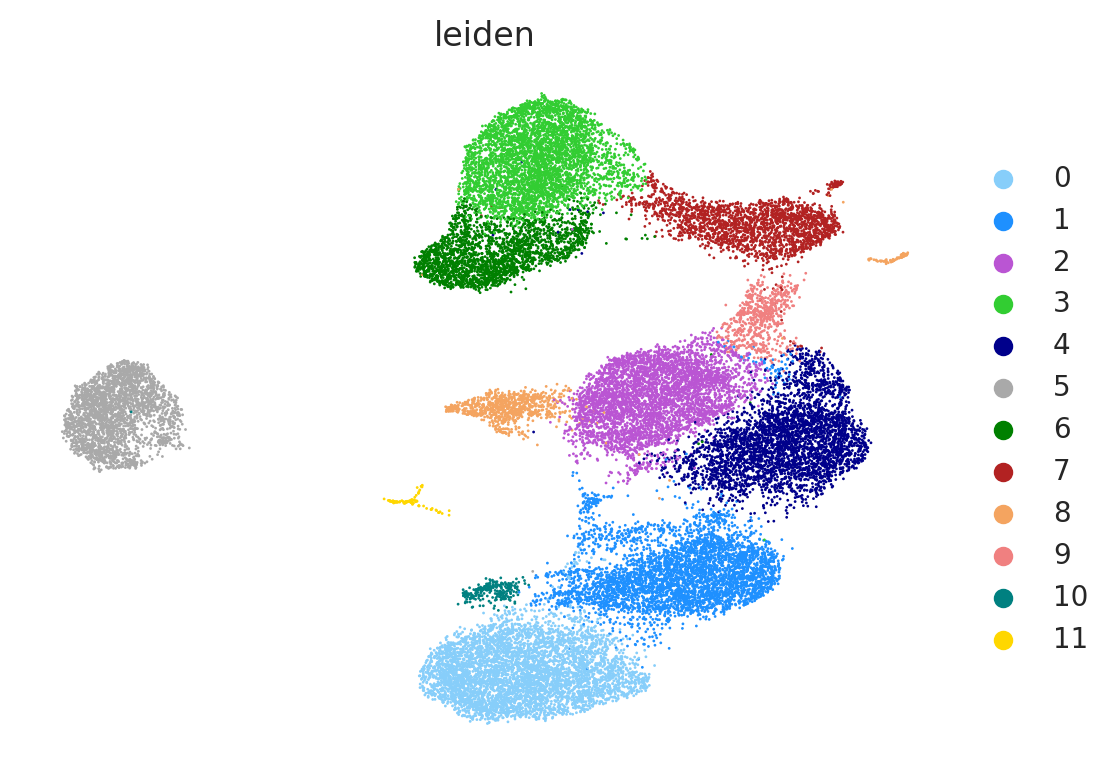

In [4]:
sc.pl.umap(oracle.adata, color=['leiden'], frameon=False)

In [51]:
def find_single_TF_enrichment(cluster_pair):
    enrichment_df = pd.DataFrame(cc_dict[cluster_pair][1], columns=['TF', 'Condition', 'ES', 'Genes'])
    enrichment_df[['Score', 'p_value']] = pd.DataFrame(enrichment_df['ES'].tolist(), index=enrichment_df.index)
    enrichment_df[['common', 'dwnstrm']] = pd.DataFrame(enrichment_df['Genes'].tolist(), index=enrichment_df.index)
    enrichment_df = enrichment_df.drop(columns=['ES', 'Genes'])
    filter_enrichment_df = (enrichment_df['p_value']<1) \
                            & (enrichment_df['dwnstrm'].apply(len)>1) & (enrichment_df['common'].apply(len)>1) \
                            & (enrichment_df['Score']>0) & (enrichment_df['Condition']==(1,))
    enrichment_df = enrichment_df[filter_enrichment_df].sort_values(by='Score', ascending=False)
    enrichment_df.to_csv(f"{out_path}/out_files/SLIDE_LF_enriched_single_TFs_{cluster_pair}.csv", index=False)

    plt.figure(figsize=(10, 6))
    plt.barh(enrichment_df['TF'].apply(lambda x: x[0]), enrichment_df['Score'], color='skyblue')
    plt.xlabel('Enrichment Score')
    plt.ylabel('TFs')
    plt.title(f'Enrichment Score of Single TFs for {cluster_pair}')
    plt.savefig(f"{out_path}/figures/SLIDE_LF_enriched_single_TFs_{cluster_pair}.pdf", dpi=300, bbox_inches='tight')
    plt.close()

In [15]:
for cluster_pair in cluster_pairs:
    combined_links = pd.concat([links_after_fit[cluster_pair[0]], links_after_fit[cluster_pair[1]]]).sort_values(by=weight, ascending=False)
    # Creating the network
    combined_links['sorted_source'] = combined_links[['source', 'target']].min(axis=1)
    combined_links['sorted_target'] = combined_links[['source', 'target']].max(axis=1)
    # Classifying the weights
    grouped_df = combined_links.groupby(['sorted_source', 'sorted_target'])[weight].apply(lambda x: classify_weights(x, min_weight_threshold)).reset_index()
    clst_pair_graph = nx.from_pandas_edgelist(grouped_df, source='sorted_source', target='sorted_target',edge_attr=weight).to_undirected()
    # Integrating SLIDE
    slide_genes_TF = list(combined_links[combined_links['target'].isin(slide_genes)]['source'].unique())
    total_source = set(slide_TF).union(set(slide_genes_TF))
    total_target = set(slide_TF).union(set(slide_genes))
    for comb_tfs in range(1,2):
        cc_dict = LF_enrichment(cc_dict, cluster_pair, comb_tfs, clst_pair_graph, total_source, total_target)

# with open(f"{out_path}/out_files/CC_dict.pkl", 'wb') as f:
#     pickle.dump(cc_dict, f)

IndexError: tuple index out of range

In [4]:
# read the CC_dict.pkl file
with open(f"{out_path}/out_files/CC_dict.pkl", 'rb') as f:
    cc_dict = pickle.load(f)
# Loading JASPAR IDs to map TF names to JASPAR IDs
jaspar_ids = pd.read_csv(f"{wd}/out_data/out_other_methods/jaspar_2024_tf_motif_id.csv", sep=',', header=None)[0].str.split('_', expand=True)
jaspar_ids['name_id'] = jaspar_ids[[1,2]].apply(lambda x: x[2]+f'({x[1]})', axis=1)
# jaspar_dict = jaspar_ids[[1,2]].apply(lambda x: x.str.upper()).set_index(2)[1].to_dict()
mapping_dict = {k: v for k, v in zip(jaspar_ids[1], jaspar_ids['name_id'])}

In [ ]:
from pathlib import Path
directory = Path(f"{wd}/out_data/out_other_methods/JASPAR2024_CORE_vertebrates_non-redundant_homer/")
file_names = {}
for f in directory.iterdir():
    if f.is_file():
        key = f.stem.split('.')[0].lower()
        value = f.stem.split('.', 1)[1]
        if key in file_names:
            file_names[key].append(value)
        else:
            file_names[key] = [value]

comb_of_interest = set()
tf_of_interest = set()
for file in glob.glob(f"{wd}/out_data/comb_ctrl/out_files/*_double_TFs_{cluster_pair}.csv"):
    df = pd.read_csv(file)
    df['TF1_mapped'] = df['TF1'].str.split('(').str[0].str.lower().map(file_names)
    df['TF2_mapped'] = df['TF2'].str.split('(').str[0].str.lower().map(file_names)
    df = df.explode('TF1_mapped').explode('TF2_mapped')
    df['TF1'] = df['TF1'].str.split('(').str[0] + '(' + df['TF1_mapped'] + ')'
    df['TF2'] = df['TF2'].str.split('(').str[0] + '(' + df['TF2_mapped'] + ')'
    comb_of_interest.update(zip(df['TF1'], df['TF2']))
    tf_of_interest.update(df['TF1_mapped'])
    tf_of_interest.update(df['TF2_mapped'])

comb_of_interest = list(comb_of_interest)
create_concatenated_pwm(tf_of_interest, cluster_pair)

In [35]:
def create_concatenated_pwm(tf_of_interest, cluster_pair):
    # Write file for  CESeek and Cicero based analysis
    output_file = f"{out_path}/out_files/concatenated_pwm_{cluster_pair}.txt"
    with open(output_file, 'w') as outfile:
        for tf_id in tf_of_interest:
            for file in os.listdir(search_directory):
                if tf_id in file or tf_id.lower() in file.lower():
                    with open(os.path.join(search_directory, file), 'r') as infile:
                        outfile.write(infile.read())

    return None

def find_double_TF_enrichment(cluster_pair):
    enrichment_df = pd.DataFrame(cc_dict[cluster_pair]['2'], columns=['TF', 'Condition', 'ES', 'Genes'])
    enrichment_df[['Score', 'p_value']] = pd.DataFrame(enrichment_df['ES'].tolist(), index=enrichment_df.index)
    enrichment_df[['common', 'dwnstrm']] = pd.DataFrame(enrichment_df['Genes'].tolist(), index=enrichment_df.index)
    enrichment_df = enrichment_df.drop(columns=['ES', 'Genes'])
    filter_enrichment_df = (enrichment_df['p_value']<0.001) \
                            & (enrichment_df['dwnstrm'].apply(len)>1) & (enrichment_df['common'].apply(len)>1) \
                            & (enrichment_df['Score']>0) \
                            & (enrichment_df['Condition'].isin([(1,1), (1,0), (0,1)]))
    enrichment_df = enrichment_df[filter_enrichment_df].sort_values(by='Score', ascending=False)
    # enrichment_df.to_csv(f"{out_path}/out_files/SLIDE_LF_enriched_double_TFs_{cluster_pair}.csv", index=False)
    # Writing for dictys analysis
    dictys_df = enrichment_df.groupby('TF').agg({'Score': 'mean', 'common': lambda x: set().union(*x), 'dwnstrm': lambda x: set().union(*x)}).reset_index()
    dictys_df.to_csv(f"{out_path}/out_files/SLIDE_LF_enriched_pair_{cluster_pair}.csv", index=False)
    # Mapping TF names to JASPAR IDs and writing for downstream analysis
    out_df = enrichment_df.groupby('TF').agg({'Score': 'mean', 'common': lambda x: len(set().union(*x)), 'dwnstrm': lambda x: len(set().union(*x))}).reset_index()
    out_df[['TF1', 'TF2']] = pd.DataFrame(out_df.pop('TF').tolist(), index=out_df.index)
    out_df[['TF1_jid', 'TF2_jid']] = out_df[['TF1', 'TF2']].apply(lambda x: x.str.upper().map(jaspar_dict))
    out_df[['TF1', 'TF2']] = out_df[['TF1_jid', 'TF2_jid']].apply(lambda x: x.str.upper().map(mapping_dict))
    out_df = out_df.dropna().reset_index(drop=True)
    out_df.to_csv(f"{out_path}/out_files/SLIDE_LF_enriched_double_TFs_{cluster_pair}.csv", index=False)
    TF_actual = set(out_df['TF1_jid']).union(set(out_df['TF2_jid']))
    return TF_actual

def create_control_pairs(cluster_pair):
    actual_TF_pairs = pd.read_csv(f"{out_path}/out_files/SLIDE_LF_enriched_double_TFs_{cluster_pair}.csv")
    n = len(actual_TF_pairs)
    # create shuffled pairs
    shuffled_TF_pairs = pd.DataFrame(columns = ['TF1', 'TF1_jid', 'TF2', 'TF2_jid'])
    indices = list(actual_TF_pairs.index)
    random.shuffle(indices)
    shuffled_TF_pairs[['TF1', 'TF1_jid']] = actual_TF_pairs[['TF1', 'TF1_jid']].iloc[indices].reset_index(drop=True)
    random.shuffle(indices)
    shuffled_TF_pairs[['TF2', 'TF2_jid']] = actual_TF_pairs[['TF2', 'TF2_jid']].iloc[indices].reset_index(drop=True)
    shuffled_TF_pairs.to_csv(f"{out_path}/out_files/shuffled_SLIDE_LF_enriched_double_TFs_{cluster_pair}.csv", index=False)
    # create random network pairs
    with open(f'{wd}/out_data/co_analysis/intermediate_data/TF_to_TG_dictionary.pkl', 'rb') as f:
        TF_to_TG_dict = pickle.load(f)
    network_scores = pd.read_csv(f'{wd}/out_data/co_analysis/out_files/ridge_fitted_2_merged_network_scores.csv')
    network_scores = network_scores[network_scores['cluster'].isin(['GC-1', 'PB-2'])]
    network_scores = network_scores.sort_values(by='degree_all', ascending=False)
    network_scores = network_scores.drop_duplicates(subset=['Unnamed: 0'], keep='first')
    network_scores ['TF_jid'] = network_scores['Unnamed: 0'].map(jaspar_dict).to_list()
    network_scores = network_scores.dropna()
    network_scores = network_scores[network_scores['degree_all'] > 50]
    network_score_pairs = random.sample(list(itertools.combinations(network_scores['Unnamed: 0'], 2)), n)
    network_score_pairs_df = pd.DataFrame(network_score_pairs, columns=['TF1', 'TF2'])
    network_score_pairs_df[['TF1_jid', 'TF2_jid']] = network_score_pairs_df[['TF1', 'TF2']].apply(lambda x: x.str.upper().map(jaspar_dict))
    network_score_pairs_df[['TF1', 'TF2']] = network_score_pairs_df[['TF1_jid', 'TF2_jid']].apply(lambda x: x.str.upper().map(mapping_dict))
    network_score_pairs_df.to_csv(f"{out_path}/out_files/CO_network_score_double_TFs_{cluster_pair}.csv", index=False)
    # create random pairs
    random_pairs = random.sample(list(itertools.combinations(mapping_dict.keys(), 2)), n)
    random_pairs_df = pd.DataFrame(random_pairs, columns=['TF1_jid', 'TF2_jid'])
    random_pairs_df[['TF1', 'TF2']] = random_pairs_df[['TF1_jid', 'TF2_jid']].apply(lambda x: x.map(mapping_dict))
    random_pairs_df.to_csv(f"{out_path}/out_files/random_double_TFs_{cluster_pair}.csv", index=False)

    TF_control = set(shuffled_TF_pairs['TF1_jid']).union(set(shuffled_TF_pairs['TF2_jid']))\
                    .union(set(network_score_pairs_df['TF1_jid'])).union(set(network_score_pairs_df['TF2_jid']))\
                    .union(set(random_pairs_df['TF1_jid'])).union(set(random_pairs_df['TF2_jid']))
    return TF_control

In [36]:
cluster_pairs = [('GC-1','PB-2' ),('PB-2', 'ActB-2'),('GC-1','ActB-2')]
search_directory = os.path.join(wd, 'out_data', 'out_other_methods', 'JASPAR2024_CORE_vertebrates_non-redundant_homer')
for cluster_pair in cluster_pairs:
    find_single_TF_enrichment(cluster_pair)
    TF_actual = find_double_TF_enrichment(cluster_pair)

In [12]:
# cluster_pairs = [('GC-1','PB-2' ),('PB-2', 'ActB-2'),('GC-1','ActB-2')]
# search_directory = os.path.join(wd, 'out_data', 'out_other_methods', 'JASPAR2024_CORE_vertebrates_non-redundant_homer')
# for cluster_pair in cluster_pairs:
#     find_single_TF_enrichment(cluster_pair)
#     TF_actual = find_double_TF_enrichment(cluster_pair)
#     TF_control = create_control_pairs(cluster_pair)
#     tf_of_interest = TF_actual.union(TF_control)
#     create_concatenated_pwm(tf_of_interest, cluster_pair)